**Fruit Recommender System ด้วย Graph** <br>แนวคิดคือ ผู้ใช้ทานหรือชอบผลไม้ชนิดไหน → หา User คนอื่นที่ชอบผลไม้คล้ายกัน → ดูว่าคนเหล่านั้นชอบผลไม้ชนิดอะไรอีก → แนะนำผลไม้ชนิดนั้นกลับมา

ตัวอย่างสถานการณ์  มีผู้ใช้ 10 คน <br>

```
Ananda
Boonchit
Chutima
Danai
boy
yu
pond
pat
poo
ya
```

และมีผลไม้ <br>
```
Mango
Apple
Durian
Banana
Grape
```

สมมติข้อมูลความชอบคือ

```
Ananda   → Mango
Ananda   → Apple

Boonchit → Mango
Boonchit → Apple
Boonchit → Banana

Chutima  → Mango
Chutima  → Durian

Danai    → Banana
Danai    → Grape

boy → Durian
boy → Grape

yu → Mango
yu → Banana

pond → Durian
pond → Apple

pat → Grape
pat → Mango

poo → Apple
poo → Banana

ya → Durian
ya → Mango
```



```
เราจะสังเกตได้ว่า

Ananda และ Boonchit ชอบ Mango และ Apple เหมือนกัน

แต่ Boonchit ยังชอบ

Banana

ดังนั้นระบบสามารถคิดง่าย ๆ ว่า

ถ้า Ananda กับ Boonchit มีความชอบคล้ายกัน
และ Boonchit ชอบ Banana แต่ Ananda ยังไม่ได้เลือก Banana
ระบบอาจแนะนำ Banana ให้ Ananda

นี่คือ Recommender System แบบ Graph อย่างง่ายค่ะ
```



การออกแบบ Graph

```
เราแบ่ง Node เป็น 2 ประเภท

User
Fruit

Relationship คือ

LIKES

ดังนั้น

(User)-[:LIKES]->(Fruit)

เช่น

(Ananda)-[:LIKES]->(Mango)

หรือถ้าเป็น Python NetworkX

G.add_edge("Ananda", "Mango")
```


**สร้างด้วย Python บน Google Colab**

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

In [ ]:
# รายชื่อผู้ใช้ทั้งหมด A-J
users = [
    "Ananda",
    "Boonchit",
    "Chutima",
    "Danai",
    "boy",
    "yu",
    "pond",
    "pat",
    "poo",
    "ya"
]

# เพิ่ม Node ของ user เข้า Graph
for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
#add fruits
fruits = [
    "Mango",
    "Apple",
    "Durian",
    "Banana",
    "Grape",
]

for fruit in fruits:
    G.add_node(
        fruit,
        node_type="fruit"
    )

In [ ]:
# รายการความสัมพันธ์ระหว่าง User และ ผลไม้ที่ชอบ
likes = [
    # Ananda
    ("Ananda", "Mango"),
    ("Ananda", "Apple"),

    # Boonchit
    ("Boonchit", "Mango"),
    ("Boonchit", "Apple"),
    ("Boonchit", "Banana"),

    # Chutima
    ("Chutima", "Mango"),
    ("Chutima", "Durian"),

    # Danai
    ("Danai", "Banana"),
    ("Danai", "Grape"),

    # Ekkapol
    ("boy", "Durian"),
    ("boy", "Grape"),

    # Fah
    ("yu", "Mango"),
    ("yu", "Banana"),

    # Guntapon
    ("pond", "Apple"),
    ("pond", "Durian"),

    # Hathai
    ("pat", "Grape"),
    ("pat", "Mango"),

    # Itsara
    ("poo", "Banana"),
    ("poo", "Apple"),

    # Jiraporn
    ("ya", "Durian"),
    ("ya", "Mango")
]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

วาด Graph

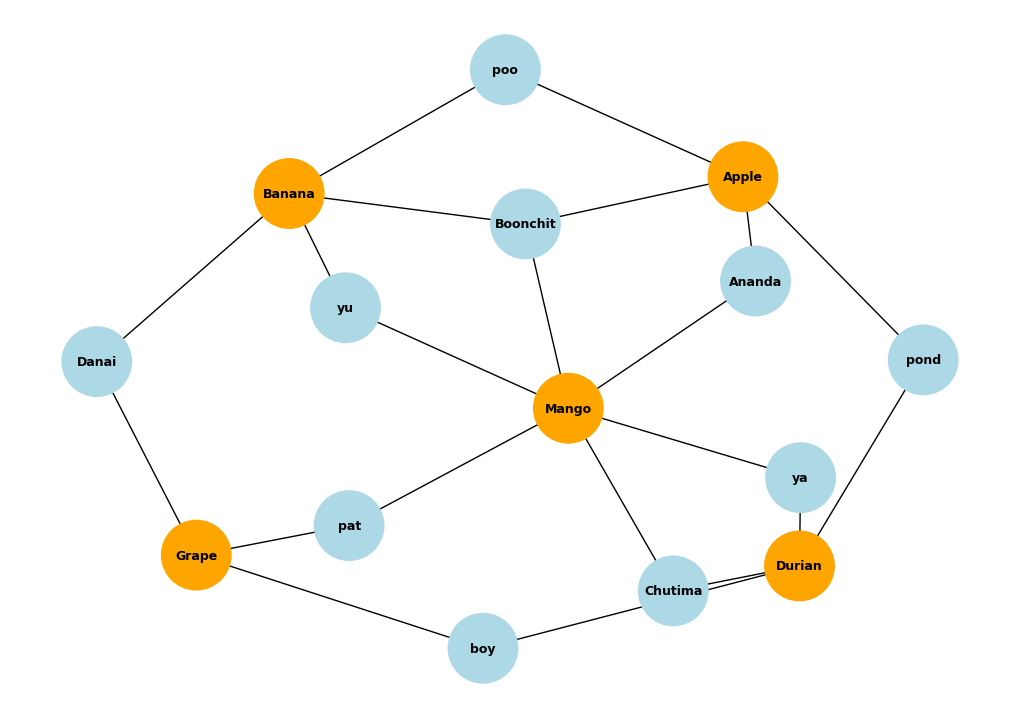

In [ ]:
# 1. กำหนดสีแยกประเภท Node
color_map = []
for node in G.nodes():
    # ถ้าเป็น User ให้ใช้สีฟ้าอ่อน (lightblue)
    if G.nodes[node].get("node_type") == "user":
        color_map.append("lightblue")
    # ถ้าเป็น ผลไม้ ให้ใช้สีส้มสดใส (orange)
    else:
        color_map.append("orange")

# 2. วาดกราฟและแสดงผล
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,  # ใส่สีที่แยกไว้
    node_size=2500,
    font_size=9,
    font_weight="bold"     # (แถม) ทำตัวหนังสือให้หนาขึ้น อ่านง่ายขึ้น
)

plt.show()

คำถามแรก <br>
1.ถามว่า Ananda ชอบผลไม้ชนิดอะไรบ้าง?

In [ ]:
ananda_fruits = list(
    G.neighbors("Ananda")
)

print(ananda_fruits)

['Mango', 'Apple']


ตรงนี้อธิบายได้ว่า Neighbor ของ Ananda คือ Node ที่เชื่อมกับ Ananda

คำถามที่ 2. หา User ที่ชอบผลไม้เหมือน Ananda <br>
Ananda ชอบ  Mango  Apple <br>
เราสามารถหาได้ว่าใครชอบผลไม้เหล่านี้เหมือนกัน

In [ ]:
for fruit in G.neighbors("Ananda"):

    print("Fruit:", fruit)

    for user in G.neighbors(fruit):

        if user != "Ananda":
            print("  Similar user:", user)

Fruit: Mango
  Similar user: Boonchit
  Similar user: Chutima
  Similar user: yu
  Similar user: pat
  Similar user: ya
Fruit: Apple
  Similar user: Boonchit
  Similar user: pond
  Similar user: poo


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

Ananda
 ↓
ผลไม้ที่ Ananda ชอบ
 ↓
User ที่ชอบผลไม้ชนิดเดียวกัน
 ↓
ผลไม้ชนิดอื่นที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ Ananda
```



In [ ]:
from collections import Counter


target_user = "Ananda"

recommendations = Counter()


# ผลไม้ที่ Ananda ชอบแล้ว
liked_fruits = set(
    G.neighbors(target_user)
)


# ดูผลไม้แต่ละชนิดที่ Ananda ชอบ
for fruit in liked_fruits:

    # หา User ที่ชอบผลไม้ชนิดเดียวกัน
    for similar_user in G.neighbors(fruit):

        if similar_user == target_user:
            continue

        # ดูว่า User คนนั้นชอบผลไม้ชนิดอะไรอีก
        for other_fruit in G.neighbors(similar_user):

            # Ananda ยังไม่เคยชอบเรื่องนี้
            if other_fruit not in liked_fruits:

                recommendations[other_fruit] += 1


print(recommendations)

Counter({'Banana': 4, 'Durian': 3, 'Grape': 1})


Durian ถูกพบจาก User ที่มีความสัมพันธ์กับ Ananda จำนวน 1 ครั้ง

In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter


def recommend_fruits(G, target_user):
    # 1. สร้างตัวนับ (Counter) สำหรับเก็บคะแนนความแนะนำของผลไม้แต่ละชนิด
    recommendations = Counter()

    # 2. ดึงรายการผลไม้ทั้งหมดที่ target_user เคยชอบ (เป็นเพื่อนกับ target_user ในกราฟ)
    liked_fruits = set(G.neighbors(target_user))

    # 3. วนลูปดูผลไม้แต่ละชนิดที่ target_user เคยชอบ
    for fruit in liked_fruits:

        # 4. วนลูปดูผู้ใช้คนอื่น (similar_user) ที่ชอบผลไม้ชนิดเดียวกันนี้ด้วย
        for similar_user in G.neighbors(fruit):

            # ข้ามตัว target_user เอง เพราะเราต้องการดูพฤติกรรมของคนอื่น
            if similar_user == target_user:
                continue

            # 5. วนลูปดูผลไม้ทั้งหมดที่ similar_user คนนั้นชอบ
            for other_fruit in G.neighbors(similar_user):

                # 6. ถ้าเป็นผลไม้ที่ target_user ยังไม่เคยชอบ/ไม่เคยลอง
                if other_fruit not in liked_fruits:

                    # 7. เพิ่มคะแนนแนะนำให้ผลไม้ชนิดนั้น +1
                    recommendations[other_fruit] += 1

    # 8. ส่งคืนรายการผลไม้เรียงลำดับจากคะแนนมากไปน้อย
    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result = recommend_fruits( G, "Ananda")
print(result)

[('Banana', 4), ('Durian', 3), ('Grape', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_fruits( G, "Chutima")
print(result)

[('Apple', 3), ('Grape', 2), ('Banana', 2)]


In [ ]:
#เรียกใช้งาน
result = recommend_fruits( G, "Boonchit")
print(result)

[('Durian', 3), ('Grape', 2)]


In [ ]:
ananda_fruits = list(
    G.neighbors("Ananda")
)

print(ananda_fruits)

['Mango', 'Apple']


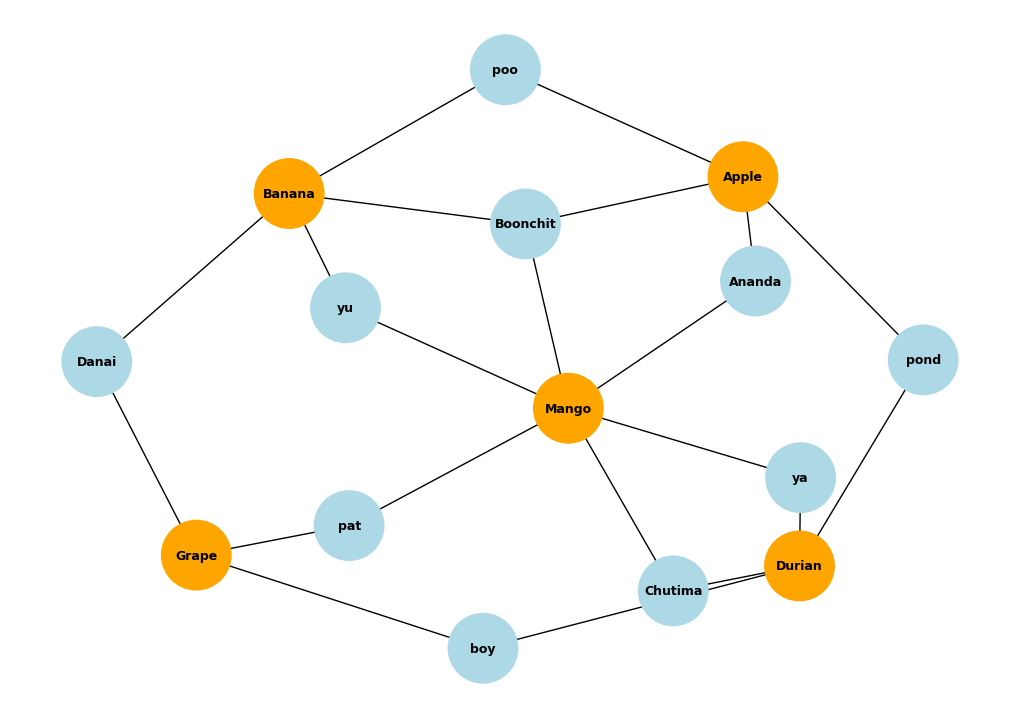

Recommendations for Boonchit
Durian Score = 3
Grape Score = 2


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users
# ==================================

users = [
    "Ananda",
    "Boonchit",
    "Chutima",
    "Danai",
    "boy",
    "yu",
    "pond",
    "pat",
    "poo",
    "ya"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Fruits
# ==================================

fruits = [
    "Mango",
    "Apple",
    "Durian",
    "Banana",
    "Grape"
]

for fruit in fruits:

    G.add_node(
        fruit,
        node_type="fruit"
    )


# ==================================
# 4. User-Fruit Relationships
# ==================================

# รายการความสัมพันธ์ระหว่าง User และ ผลไม้ที่ชอบ
likes = [
    # Ananda
    ("Ananda", "Mango"),
    ("Ananda", "Apple"),

    # Boonchit
    ("Boonchit", "Mango"),
    ("Boonchit", "Apple"),
    ("Boonchit", "Banana"),

    # Chutima
    ("Chutima", "Mango"),
    ("Chutima", "Durian"),

    # Danai
    ("Danai", "Banana"),
    ("Danai", "Grape"),

    # Ekkapol
    ("boy", "Durian"),
    ("boy", "Grape"),

    # Fah
    ("yu", "Mango"),
    ("yu", "Banana"),

    # Guntapon
    ("pond", "Apple"),
    ("pond", "Durian"),

    # Hathai
    ("pat", "Grape"),
    ("pat", "Mango"),

    # Itsara
    ("poo", "Banana"),
    ("poo", "Apple"),

    # Jiraporn
    ("ya", "Durian"),
    ("ya", "Mango")
]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

# 1. กำหนดสีแยกประเภท Node
color_map = []
for node in G.nodes():
    # ถ้าเป็น User ให้ใช้สีฟ้าอ่อน (lightblue)
    if G.nodes[node].get("node_type") == "user":
        color_map.append("lightblue")
    # ถ้าเป็น ผลไม้ ให้ใช้สี (orange)
    else:
        color_map.append("orange")

# 2. วาดกราฟและแสดงผล
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=2500,
    font_size=9,
    font_weight="bold"
)

plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_fruits(G, target_user):
    """
    ฟังก์ชันแนะนำผลไม้สำหรับผู้ใช้เป้าหมาย (target_user)
    โดยคำนวณจากกราฟความสัมพันธ์ (G) ระหว่างผู้ใช้และผลไม้
    """

    # ใช้ Counter เพื่อเก็บและนับคะแนนการแนะนำของผลไม้แต่ละชนิด
    recommendations = Counter()

    # 1. หาผลไม้ทั้งหมดที่ target_user เคยชอบ/เคยเลือกไว้แล้ว
    # (neighbors ของ node ผู้ใช้ในกราฟ คือ node ผลไม้ที่เชื่อมกันอยู่)
    liked_fruits = set(G.neighbors(target_user))

    # 2. วนลูปดูผลไม้แต่ละชนิดที่ target_user เคยชอบ
    for fruit in liked_fruits:

        # 3. หาผู้ใช้คนอื่น (similar_user) ที่ชอบผลไม้ชนิดนี้เหมือนกัน
        for similar_user in G.neighbors(fruit):

            # ข้าม target_user ตัวเอง (ไม่นำมาเปรียบเทียบกับตัวเอง)
            if similar_user == target_user:
                continue

            # 4. ดูว่าผู้ใช้ที่มีรสนิยมคล้ายกัน (similar_user) ชอบผลไม้อะไรอีกบ้าง
            for other_fruit in G.neighbors(similar_user):

                # 5. กรองเอาเฉพาะผลไม้ที่ target_user ยังไม่เคยชอบ/ยังไม่เคยเลือก
                if other_fruit not in liked_fruits:

                    # เพิ่มคะแนนให้กับผลไม้นั้น (+1 คะแนนต่อหนึ่งเส้นทางเชื่อมโยง)
                    recommendations[other_fruit] += 1

    # คืนค่าผลไม้ที่ได้รับการแนะนำ เรียงลำดับจากคะแนนมากไปน้อย (Most Common)
    return recommendations.most_common()


# ==================================
# 7. Recommend for Ananda (การเรียกใช้งานฟังก์ชันเพื่อแนะนำผลไม้)
# ==================================

# กำหนดผู้ใช้เป้าหมายที่ต้องการหาผลไม้แนะนำ
target_user = "Boonchit"

# เรียกใช้ฟังก์ชัน recommend_fruits เพื่อคำนวณหาผลไม้ที่แนะนำพร้อมคะแนน
result = recommend_fruits(
    G,
    target_user
)

# แสดงหัวข้อรายงานผลการแนะนำสำหรับผู้ใช้เป้าหมาย
print(
    "Recommendations for",
    target_user
)

# วนลูปเพื่อดึงชื่อผลไม้ (fruit) และคะแนน (score) ที่ได้จาก result มาแสดงผลทีละรายการ
for fruit, score in result:

    print(
        fruit,
        "Score =",
        score
    )

Recommender System แบบ Graph ไม่ได้มองเพียงว่า “ผลไม้ชนิดไหนดี” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้และผลไม้ชนิดอื่นอย่างไร”